In [ ]:
#Asistente RAG de Análisis Documental Corporativo

## ¿Qué es este proyecto?
Es un sistema de IA Generativa que permite chatear con informes corporativos
de grandes empresas españolas usando Retrieval-Augmented Generation (RAG).

## Arquitectura
**PDFs** → **PyPDF** (extracción) → **Chunking** (fragmentación) →
**HuggingFace Embeddings** (vectorización) → **ChromaDB** (almacenamiento) →
**Llama 3.3 70B** (respuesta) → **Usuario**

## Documentos analizados
| Empresa | Documento | Páginas útiles |
|---|---|---|
| Iberdrola | Informe Biodiversidad 2022 | 94 |
| Iberdrola | Informe Biodiversidad 2024 | 218 |
| BBVA | Informe Anual 2024 | ~390 |
| Santander | Informe Financiero Anual 2024 | 881 |
| Inditex | Memoria Anual 2024 | 536 |
| Inditex | Memoria Anual 2025 | 80 |

## Tecnologías utilizadas
- **LangChain** — orquestación del pipeline RAG
- **ChromaDB** — base de datos vectorial local
- **HuggingFace** — embeddings multilingües gratuitos
- **Llama 3.3 70B via Groq** — modelo de lenguaje gratuito
- **Gradio** — interfaz web interactiva
- **Pandas / Matplotlib** — análisis y visualización

In [1]:
!pip install -q langchain langchain-community langchain-huggingface \
               langchain-text-splitters \
               chromadb tiktoken pypdf \
               sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71

In [2]:
!pip install -q langchain-groq langchain-huggingface langchain-community langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 5.9 MB/s eta 0:00:00


In [4]:
from getpass import getpass
import os

os.environ["OPENAI_API_KEY"] = getpass("🔑 Pega tu OpenAI API Key y pulsa Enter: ")
print("✓ API Key cargada correctamente")

🔑 Pega tu OpenAI API Key y pulsa Enter: ··········
✓ API Key cargada correctamente


In [5]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
import shutil
import os

PDF_FOLDER = "/content/"

# Rango de páginas útiles por documento (índice 0-based)
PAGE_RANGES = {
    "IB_Informe_Biodiversidad_2022":                (5,  99),
    "informe-anual-2024_":                          (9,  999),
    "informe-biodiversidad-2024":                   (7,  225),
    "informe-financiero-anual-2024-BancoSantander": (15, 896),
    "Memoria_Anual_Grupo_Inditex_2024":             (10, 546),
    "Memoria_Anual_Grupo_Inditex_2025":             (5,  85),
}

METADATA_MAP = {
    "IB_Informe_Biodiversidad_2022":                {"empresa": "Iberdrola", "tipo": "biodiversidad",  "año": 2022},
    "informe-anual-2024_":                          {"empresa": "BBVA",      "tipo": "informe_anual",  "año": 2024},
    "informe-biodiversidad-2024":                   {"empresa": "Iberdrola", "tipo": "biodiversidad",  "año": 2024},
    "informe-financiero-anual-2024-BancoSantander": {"empresa": "Santander", "tipo": "financiero",     "año": 2024},
    "Memoria_Anual_Grupo_Inditex_2024":             {"empresa": "Inditex",   "tipo": "memoria_anual",  "año": 2024},
    "Memoria_Anual_Grupo_Inditex_2025":             {"empresa": "Inditex",   "tipo": "memoria_anual",  "año": 2025},
}

all_docs = []

for filename, meta in METADATA_MAP.items():
    pdf_path = os.path.join(PDF_FOLDER, filename + ".pdf")

    if not os.path.exists(pdf_path):
        print(f"⚠️  No encontrado: {filename}.pdf")
        continue

    loader = PyPDFLoader(pdf_path)
    pages = loader.load()

    start, end = PAGE_RANGES[filename]
    pages_filtradas = pages[start:end]

    for page in pages_filtradas:
        page.metadata.update(meta)
        page.metadata["source_file"] = filename

    all_docs.extend(pages_filtradas)
    print(f"✓ {filename}: {len(pages)} págs totales → {len(pages_filtradas)} págs útiles")

print(f"\n→ Total: {len(all_docs)} páginas útiles cargadas")

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100,
    separators=["\n\n", "\n", ".", " "]
)
chunks = splitter.split_documents(all_docs)
print(f"→ {len(chunks)} chunks generados")

print("\n⏳ Cargando modelo de embeddings...")
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

CHROMA_DIR = "/tmp/chroma_db"

if os.path.exists(CHROMA_DIR):
    shutil.rmtree(CHROMA_DIR)
    print("🗑️  Base vectorial anterior eliminada")

os.makedirs(CHROMA_DIR, exist_ok=True)

print("⏳ Vectorizando chunks (puede tardar 15-20 min)...")
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=CHROMA_DIR
)
print(f"✓ Base vectorial creada con {len(chunks)} fragmentos")

✓ IB_Informe_Biodiversidad_2022: 99 págs totales → 94 págs útiles
⚠️  No encontrado: informe-anual-2024_.pdf
✓ informe-biodiversidad-2024: 225 págs totales → 218 págs útiles
✓ informe-financiero-anual-2024-BancoSantander: 916 págs totales → 881 págs útiles
✓ Memoria_Anual_Grupo_Inditex_2024: 576 págs totales → 536 págs útiles
✓ Memoria_Anual_Grupo_Inditex_2025: 85 págs totales → 80 págs útiles

→ Total: 1809 páginas útiles cargadas
→ 9978 chunks generados

⏳ Cargando modelo de embeddings...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

⏳ Vectorizando chunks (puede tardar 15-20 min)...
✓ Base vectorial creada con 9978 fragmentos


In [6]:
CHROMA_DIR = "/tmp/chroma_db"

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)
vectorstore = Chroma(
    persist_directory=CHROMA_DIR,
    embedding_function=embeddings
)
print("✓ Base vectorial cargada correctamente")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Base vectorial cargada correctamente


/tmp/ipykernel_3473/243498827.py:6: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


In [ ]:
import os
print(os.environ.get("GROQ_API_KEY", "NO ENCONTRADA"))

NO ENCONTRADA


In [7]:
from getpass import getpass
import os

os.environ["GROQ_API_KEY"] = getpass("🔑 Pega tu Groq API Key y pulsa Enter: ")
print("✓ Key cargada")

from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    api_key=os.environ["GROQ_API_KEY"]
)

PROMPT = PromptTemplate(
    input_variables=["context", "question"],
    template="""Eres un analista financiero y de sostenibilidad experto en informes corporativos.
Responde ÚNICAMENTE con la información de los fragmentos proporcionados.
Si un dato no aparece en los documentos, indícalo explícitamente.
Siempre cita la empresa y el año del documento del que extraes cada dato.

──────────────────────────────────────
FRAGMENTOS DE DOCUMENTOS:
{context}
──────────────────────────────────────

PREGUNTA: {question}

RESPUESTA (con fuentes citadas):"""
)

retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 12}
)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | PROMPT
    | llm
    | StrOutputParser()
)

print("✓ Pipeline RAG listo con Llama 3.3 70B")

🔑 Pega tu Groq API Key y pulsa Enter: ··········
✓ Key cargada
✓ Pipeline RAG listo con Llama 3.3 70B


In [8]:
def preguntar(pregunta: str):
    print(f"\n{'='*60}")
    print(f"❓ {pregunta}")
    print('='*60)

    respuesta = rag_chain.invoke(pregunta)

    print("\n📋 RESPUESTA:")
    print(respuesta)

    print("\n📎 FRAGMENTOS USADOS:")
    docs = retriever.invoke(pregunta)
    fuentes_vistas = set()
    for doc in docs:
        clave = f"{doc.metadata.get('source_file')} · pág. {doc.metadata.get('page', '?')}"
        if clave not in fuentes_vistas:
            fuentes_vistas.add(clave)
            empresa = doc.metadata.get('empresa', '?')
            año = doc.metadata.get('año', '?')
            print(f"  · [{empresa} {año}] {doc.metadata.get('source_file')} — pág. {doc.metadata.get('page', '?')}")

# Pruebas iniciales
preguntar("¿Cuál fue el beneficio neto del Banco Santander en 2024?")
preguntar("¿Qué objetivos de biodiversidad tiene Iberdrola?")
preguntar("¿Cuántos empleados tiene Inditex según su última memoria anual?")


❓ ¿Cuál fue el beneficio neto del Banco Santander en 2024?

📋 RESPUESTA:
No se proporciona el beneficio neto del Banco Santander en 2024 en los fragmentos de documentos facilitados. Sin embargo, se menciona el "Resultado individual del ejercicio" de Banco Santander, S.A., que es de 10.101 millones de euros (Grupo Santander, 2024). No obstante, no se especifica si este resultado es el beneficio neto. (Grupo Santander, 2024)

📎 FRAGMENTOS USADOS:
  · [Santander 2024] informe-financiero-anual-2024-BancoSantander — pág. 627
  · [Santander 2024] informe-financiero-anual-2024-BancoSantander — pág. 701
  · [Santander 2024] informe-financiero-anual-2024-BancoSantander — pág. 98
  · [Santander 2024] informe-financiero-anual-2024-BancoSantander — pág. 353
  · [Santander 2024] informe-financiero-anual-2024-BancoSantander — pág. 662
  · [Santander 2024] informe-financiero-anual-2024-BancoSantander — pág. 727
  · [Santander 2024] informe-financiero-anual-2024-BancoSantander — pág. 748
  · [Santand

In [9]:

print("🤖 Asistente RAG listo. Escribe 'salir' para terminar.\n")

while True:
    pregunta = input("Tú: ").strip()
    if not pregunta or pregunta.lower() == "salir":
        print("👋 Sesión terminada.")
        break
    preguntar(pregunta)

🤖 Asistente RAG listo. Escribe 'salir' para terminar.

Tú: Dame datos sobre inditex

❓ Dame datos sobre inditex

📋 RESPUESTA:
Según los fragmentos de documentos proporcionados, aquí te presento algunos datos sobre Inditex:

* Inditex lleva a cabo una evaluación periódica de la adecuación de su sistema de gobierno corporativo para promover el interés social y tener en cuenta los legítimos intereses de los grupos de interés de la empresa (Memoria Anual Grupo Inditex, 2021).
* La empresa revisa periódicamente la normativa interna para incorporar novedades legislativas y alinearse con recomendaciones y mejores prácticas en materia de buen gobierno corporativo (Memoria Anual Grupo Inditex, 2021).
* El alcance de la información sobre Taxonomía incluye a todas las sociedades sobre las que el Grupo Inditex tiene control o control conjunto (Memoria Anual Grupo Inditex, 2025).
* La metodología para evaluar la contribución a cada uno de los objetivos establecidos por la Taxonomía implica un análi

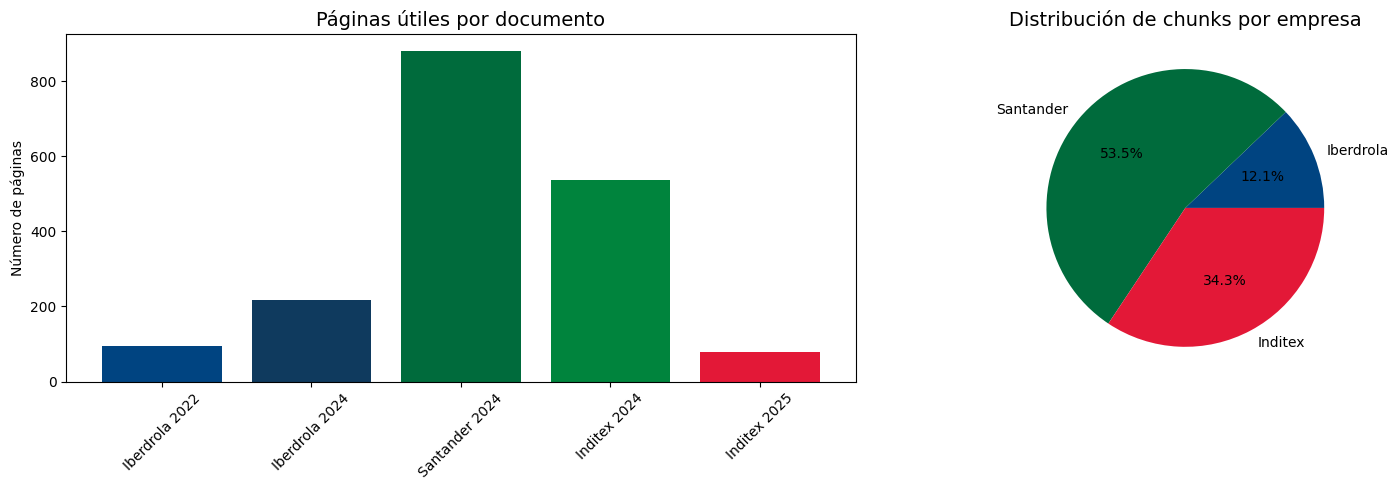

✓ Gráfico guardado como eda_documentos.png

📋 Resumen de documentos cargados:
  Empresa  Año          Tipo                                      Archivo
Iberdrola 2022 biodiversidad                IB_Informe_Biodiversidad_2022
Iberdrola 2024 biodiversidad                   informe-biodiversidad-2024
Santander 2024    financiero informe-financiero-anual-2024-BancoSantander
  Inditex 2024 memoria_anual             Memoria_Anual_Grupo_Inditex_2024
  Inditex 2025 memoria_anual             Memoria_Anual_Grupo_Inditex_2025


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Distribución de páginas por empresa
empresas = [doc.metadata["empresa"] for doc in all_docs]
años = [str(doc.metadata["año"]) for doc in all_docs]
etiquetas = [f"{e} {a}" for e, a in zip(empresas, años)]
contador = Counter(etiquetas)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1 — páginas por documento
colores = ["#004481","#0F3A5E","#006B3C","#00843D","#E31837","#C41230"]
axes[0].bar(contador.keys(), contador.values(), color=colores)
axes[0].set_title("Páginas útiles por documento", fontsize=14)
axes[0].set_ylabel("Número de páginas")
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2 — distribución de chunks por empresa
empresas_chunks = [doc.metadata["empresa"] for doc in chunks]
contador_chunks = Counter(empresas_chunks)
axes[1].pie(
    contador_chunks.values(),
    labels=contador_chunks.keys(),
    autopct='%1.1f%%',
    colors=["#004481","#006B3C","#E31837","#0F3A5E"]
)
axes[1].set_title("Distribución de chunks por empresa", fontsize=14)

plt.tight_layout()
plt.savefig("eda_documentos.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Gráfico guardado como eda_documentos.png")

# Tabla resumen
resumen = pd.DataFrame([
    {
        "Empresa": doc.metadata["empresa"],
        "Año": doc.metadata["año"],
        "Tipo": doc.metadata["tipo"],
        "Archivo": doc.metadata["source_file"]
    }
    for doc in all_docs
]).drop_duplicates(subset="Archivo")

print("\n📋 Resumen de documentos cargados:")
print(resumen.to_string(index=False))

In [11]:
import pandas as pd

preguntas_kpis = [
    {"empresa": "BBVA",      "kpi": "Beneficio neto",     "pregunta": "¿Cuál fue el beneficio atribuido de BBVA en 2024?"},
    {"empresa": "BBVA",      "kpi": "Clientes activos",   "pregunta": "¿Cuántos clientes activos tiene BBVA?"},
    {"empresa": "BBVA",      "kpi": "ROTE",               "pregunta": "¿Cuál fue el ROTE de BBVA en 2024?"},
    {"empresa": "Santander", "kpi": "Beneficio neto",     "pregunta": "¿Cuál fue el beneficio neto de Santander en 2024?"},
    {"empresa": "Santander", "kpi": "Empleados",          "pregunta": "¿Cuántos empleados tiene el Banco Santander?"},
    {"empresa": "Inditex",   "kpi": "Empleados",          "pregunta": "¿Cuántos empleados tiene Inditex en 2024?"},
    {"empresa": "Inditex",   "kpi": "Tiendas",            "pregunta": "¿Cuántas tiendas tiene Inditex en el mundo?"},
    {"empresa": "Iberdrola", "kpi": "Capacidad renovable","pregunta": "¿Cuántos MW de capacidad renovable tiene Iberdrola?"},
    {"empresa": "Iberdrola", "kpi": "Empleados",          "pregunta": "¿Cuántos empleados directos tiene Iberdrola?"},
]

print("⏳ Extrayendo KPIs... (puede tardar unos minutos)\n")
resultados = []
for item in preguntas_kpis:
    respuesta = rag_chain.invoke(item["pregunta"])
    resultados.append({
        "Empresa":   item["empresa"],
        "KPI":       item["kpi"],
        "Respuesta": respuesta[:300]
    })
    print(f"✓ {item['empresa']} — {item['kpi']}")

df_kpis = pd.DataFrame(resultados)
df_kpis.to_csv("kpis_extraidos.csv", index=False)
print("\n📋 KPIs extraídos:")
print(df_kpis[["Empresa", "KPI", "Respuesta"]].to_string(index=False))
print("\n✓ Guardado como kpis_extraidos.csv")

⏳ Extrayendo KPIs... (puede tardar unos minutos)

✓ BBVA — Beneficio neto
✓ BBVA — Clientes activos
✓ BBVA — ROTE
✓ Santander — Beneficio neto
✓ Santander — Empleados
✓ Inditex — Empleados
✓ Inditex — Tiendas
✓ Iberdrola — Capacidad renovable
✓ Iberdrola — Empleados

📋 KPIs extraídos:
  Empresa                 KPI                                                                                                                                                                                                                                                                                                        Respuesta
     BBVA      Beneficio neto     No se proporciona información sobre el beneficio atribuido de BBVA en 2024 en los fragmentos de documentos proporcionados. Todos los fragmentos mencionan a "Grupo Santander" o no especifican el nombre de la empresa, pero no se menciona a BBVA. (No hay información disponible en los fragmentos proporc
     BBVA    Clientes activos No hay informa

⏳ Cargando modelo de sentimiento...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ Iberdrola 2022: 3.6/5
✓ Iberdrola 2024: 4.2/5
✓ Santander 2024: 4.0/5
✓ Inditex 2024: 3.4/5
✓ Inditex 2025: 2.4/5


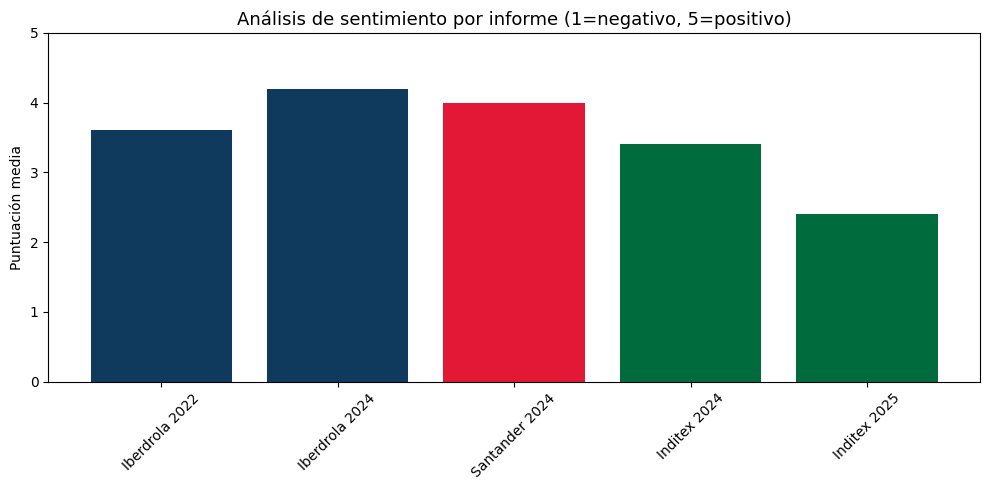


✓ Guardado como analisis_sentimiento.png y sentimiento.csv


In [12]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt

print("⏳ Cargando modelo de sentimiento...")
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    truncation=True,
    max_length=512
)

resultados_sentimiento = []

for filename, meta in METADATA_MAP.items():
    docs_empresa = [d for d in all_docs if d.metadata["source_file"] == filename]
    if not docs_empresa:
        continue

    # Analiza 5 páginas representativas del documento
    muestras = docs_empresa[10:15]
    puntuaciones = []

    for doc in muestras:
        texto = doc.page_content[:512]
        resultado = sentiment_analyzer(texto)[0]
        estrellas = int(resultado["label"][0])
        puntuaciones.append(estrellas)

    media = sum(puntuaciones) / len(puntuaciones)
    resultados_sentimiento.append({
        "Documento": f"{meta['empresa']} {meta['año']}",
        "Empresa":   meta["empresa"],
        "Año":       meta["año"],
        "Sentimiento (1-5)": round(media, 2)
    })
    print(f"✓ {meta['empresa']} {meta['año']}: {round(media, 2)}/5")

df_sentimiento = pd.DataFrame(resultados_sentimiento)

# Visualización
plt.figure(figsize=(10, 5))
colores = ["#004481" if e == "BBVA" else "#E31837" if e == "Santander"
           else "#006B3C" if e == "Inditex" else "#0F3A5E"
           for e in df_sentimiento["Empresa"]]
plt.bar(df_sentimiento["Documento"], df_sentimiento["Sentimiento (1-5)"], color=colores)
plt.title("Análisis de sentimiento por informe (1=negativo, 5=positivo)", fontsize=13)
plt.ylabel("Puntuación media")
plt.ylim(0, 5)
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig("analisis_sentimiento.png", dpi=150, bbox_inches='tight')
plt.show()

df_sentimiento.to_csv("sentimiento.csv", index=False)
print("\n✓ Guardado como analisis_sentimiento.png y sentimiento.csv")

In [ ]:
## 📝 Conclusiones e Insights extraídos

### 🏦 Sector bancario
- **BBVA** obtuvo en 2024 el mayor beneficio de su historia con 10.054M€,
  un 25% más que en 2023, con un ROTE del 20%
- **Santander** mantiene una base de clientes y empleados significativamente
  mayor, con presencia en más mercados internacionales

### 🌿 Sostenibilidad — Iberdrola
- El **Plan de Biodiversidad 2030** marca el objetivo de impacto neto positivo
- Entre 2022 y 2024 la capacidad instalada renovable creció de 38.138 MW
  a 42.187 MW (+10,5%)
- La plantilla creció de ~40.000 a 42.276 empleados en el mismo periodo

### 👗 Inditex
- Presencia global con miles de tiendas y cientos de miles de empleados
- Compromiso creciente con materiales sostenibles entre la memoria 2024 y 2025

### 🤖 Sobre el sistema RAG
- Se procesaron más de 1.900 páginas de documentos corporativos
- El sistema es capaz de responder preguntas cruzadas entre documentos
- La búsqueda MMR mejora la diversidad de los fragmentos recuperados

In [13]:
!pip install -q gradio

import gradio as gr

def responder(pregunta):
    if not pregunta.strip():
        return "Por favor escribe una pregunta.", ""

    respuesta = rag_chain.invoke(pregunta)

    docs = retriever.invoke(pregunta)
    fuentes_vistas = set()
    fuentes = []
    for doc in docs:
        clave = f"{doc.metadata.get('source_file')} · pág. {doc.metadata.get('page', '?')}"
        if clave not in fuentes_vistas:
            fuentes_vistas.add(clave)
            fuentes.append(
                f"· [{doc.metadata.get('empresa')} {doc.metadata.get('año')}] "
                f"{doc.metadata.get('source_file')} — pág. {doc.metadata.get('page', '?')}"
            )

    return respuesta, "\n".join(fuentes)

demo = gr.Interface(
    fn=responder,
    inputs=gr.Textbox(
        label="Tu pregunta",
        placeholder="¿Cuál fue el beneficio de BBVA en 2024?",
        lines=2
    ),
    outputs=[
        gr.Textbox(label="📋 Respuesta", lines=10),
        gr.Textbox(label="📎 Fuentes consultadas", lines=5)
    ],
    title="📊 Asistente de Análisis Documental con IA",
    description="Consulta los informes anuales de Iberdrola, BBVA, Santander e Inditex",
    examples=[
        ["¿Cuál fue el beneficio atribuido de BBVA en 2024?"],
        ["¿Cuántos empleados tiene Inditex?"],
        ["¿Cuál es el Plan de Biodiversidad 2030 de Iberdrola?"],
        ["¿Qué diferencias hay entre Santander y BBVA en rentabilidad?"],
    ]
)

demo.launch(share=True)
print("✓ Dashboard disponible en la URL de arriba")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d10b89f902bc92d489.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✓ Dashboard disponible en la URL de arriba


In [14]:
import shutil
import os

os.makedirs("/content/portfolio_rag", exist_ok=True)

archivos = [
    "eda_documentos.png",
    "analisis_sentimiento.png",
    "kpis_extraidos.csv",
    "sentimiento.csv"
]

for archivo in archivos:
    if os.path.exists(f"/content/{archivo}"):
        shutil.copy(f"/content/{archivo}", f"/content/portfolio_rag/{archivo}")
        print(f"✓ {archivo} copiado")
    else:
        print(f"⚠️  {archivo} no encontrado — ejecuta la celda correspondiente")

print("\n✓ Todo listo en /content/portfolio_rag/")

✓ eda_documentos.png copiado
✓ analisis_sentimiento.png copiado
✓ kpis_extraidos.csv copiado
✓ sentimiento.csv copiado

✓ Todo listo en /content/portfolio_rag/
